In [3]:
%matplotlib inline

In [4]:
%load_ext autoreload
%autoreload 2
%aimport

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Modules to reload:
all-except-skipped

Modules to skip:



In [16]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

proj_root = f'{os.environ["HOME"]}/work/gitlab/timer'
sys.path.append(proj_root)

setting default: fixed = ['period', 'u_star']
setting default: fit_basis = duration
setting default: chromatic = False
setting default: include_mean = True
setting default: include_flare = False
setting default: use_gp = False
setting default: tune = 2000
setting default: draws = 2000
setting default: chains = 2
setting default: inferencedata = False
setting default for s25-1: add_bias = False
setting default for s25-1: quadratic = False
setting default for s25-1: trim_beg = None
setting default for s25-1: trim_end = None
setting default for s25-1: nsig_clip = 7
setting default for s25-1: binsize = 0.003472222222222222
setting default for s25-1: chunk_offset = False
setting default for s25-1: chunk_thresh = 0
loading data: TESS20200521.txt
data span: 2020-05-21 01:40:03.199 - 2020-05-21 13:34:03.147
ref. time: 2458990
building and optimizing model
dur_interval__                     -1.39
t0_interval__                      -1.39
ror_interval__                     -1.39
b_interval__     

optimizing logp for variables: [s25-1_log_sigma_lc, s25-1_weights, s25-1_mean, b, ror, t0, dur]


message: Optimization terminated successfully.
logp: -1926.9229031101347 -> -206.93048852523202


               dur_interval__ ~ TransformedDistribution
                t0_interval__ ~ TransformedDistribution
               ror_interval__ ~ TransformedDistribution
                 b_interval__ ~ TransformedDistribution
                   s25-1_mean ~ Normal
                s25-1_weights ~ Normal
s25-1_log_sigma_lc_interval__ ~ TransformedDistribution
                          dur ~ Uniform
                           t0 ~ Uniform
                          ror ~ Uniform
                            b ~ Uniform
                     s25-1_lm ~ Deterministic
           s25-1_log_sigma_lc ~ Uniform
           s25-1_light_curves ~ Deterministic
        s25-1_light_curves_hr ~ Deterministic
                s25-1_lc_pred ~ Deterministic
                     rho_circ ~ Deterministic
             s25-1_y_observed ~ Normal


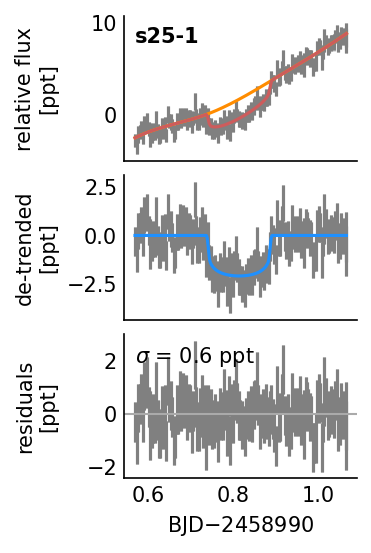

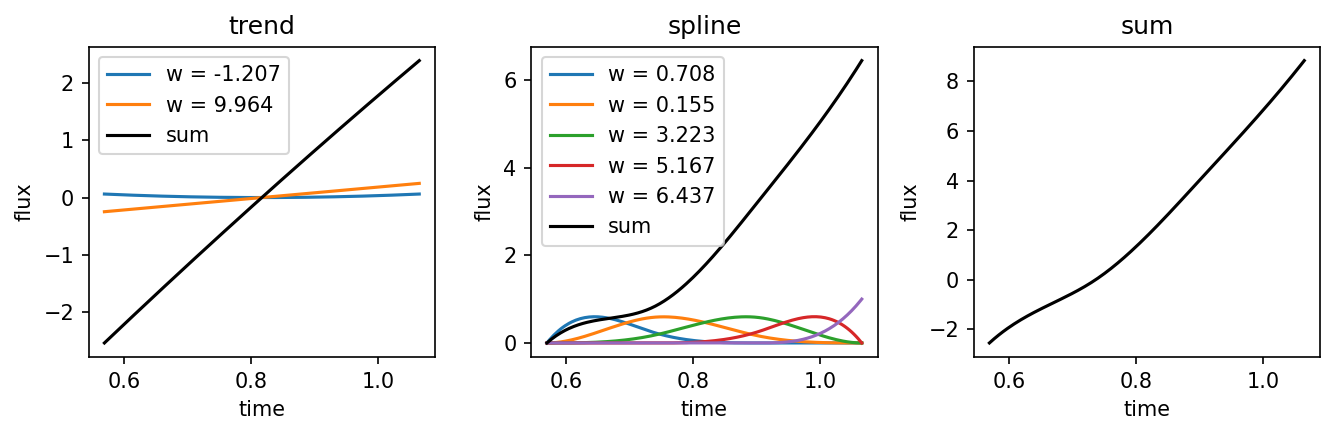

In [152]:
from timer.fit import TransitFit

wd = os.path.join(proj_root, 'examples/v1298tau-m2')
fp = f'{wd}/fit.yaml'
fit_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fp = f'{wd}/sys.yaml'
sys_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fit_params['clobber'] = True
fit_params['cores'] = 1
fit = TransitFit(sys_params, fit_params, wd=wd)
fit.build_model()
for name in fit.data.keys():
    fit.plot_systematics(name, style=2)

In [138]:
trend = fit.fit_params['data'][name]['trend']
ntrend = trend if trend else 0
spline = fit.fit_params['data'][name]['spline']
nspline = 5 if spline else 0    
bias = fit.fit_params['data'][name]['add_bias']
nbias = 1 if bias else 0

x = fit.data[name]['x']
X = fit.data[name]['X']
mask = fit.masks[name] 
if mask is None:
    mask = np.ones(len(x), dtype=bool)
w = fit.map_soln[f'{name}_weights']
covariates = not X.shape[1] == nspline + ntrend + nbias
ncovariates = X.shape[1] - ntrend - nspline - nbias

x_ = x[mask]
X_cov = X[mask,:ncovariates]
w_cov = w[:ncovariates]
X_tre = X[mask,ncovariates:(ncovariates+ntrend)]
w_tre = w[ncovariates:(ncovariates+ntrend)]
X_spl = X[mask,(ncovariates+ntrend):(ncovariates+ntrend+nspline)]
w_spl = w[(ncovariates+ntrend):(ncovariates+ntrend+nspline)]

w_cov.shape, w_tre.shape, w_spl.shape

# X.shape, covariates, trend, spline, bias

((5,), (1,), (5,))

In [102]:
X_spl.shape

(144, 5)

In [103]:
# X.shape
ncovariates, (ncovariates+ntrend)
# X[mask,ncovariates:(ncovariates+ntrend)].shape
# X_tre.shape
# np.dot(X_tre,w_tre)

(0, 1)

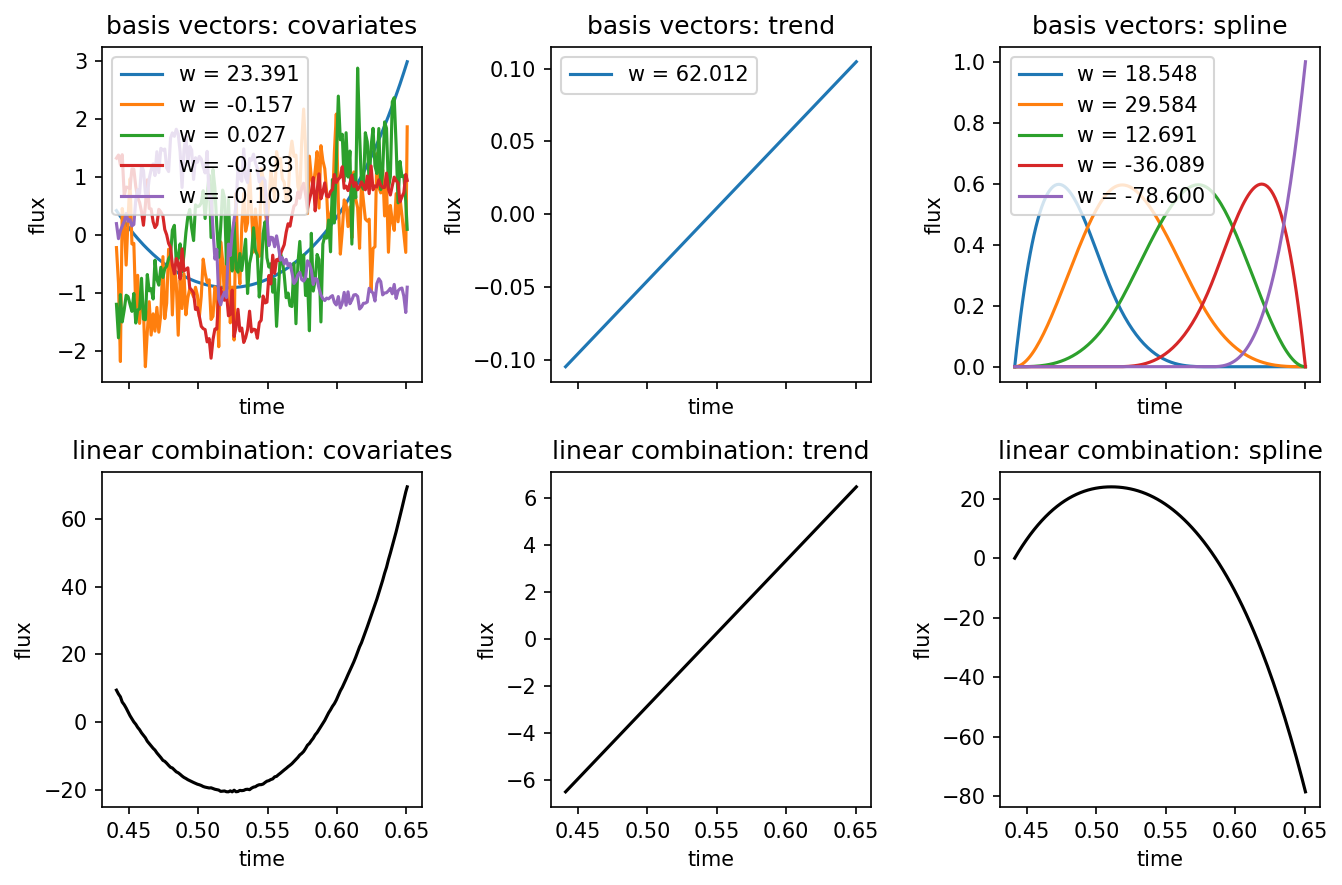

In [134]:

ncols = sum([covariates, (trend is not None), spline])
figsize = (3*ncols,6)
fig, axs = plt.subplots(2, ncols, figsize=figsize, sharex=True)

def plot(axs, x, X, w, name):
    for i,y in enumerate(X.T):
        axs[0].plot(x, y, label=f'w = {w[i] :.3f}')
    axs[0].legend()
    axs[1].plot(x, np.dot(X,w), color='k')
    plt.setp(axs[0], title=f'basis vectors: {name}')
    plt.setp(axs[1], title=f'linear combination: {name}')
    
if covariates and not spline and not trend:
    plot(axs, x_, X_cov, w_cov, 'covariates')

elif spline and not covariates and not trend:
    plot(axs, x_, X_spl, w_spl, 'spline')

elif trend and not covariates and not spline:
    plot(axs, x_, X_tre, w_tre, 'trend')

elif covariates and spline and not trend:
    plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
    plot(axs[:,1], x_, X_spl, w_spl, 'spline')

elif covariates and trend and not spline:
    plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
    plot(axs[:,1], x_, X_tre, w_tre, 'trend')

elif trend and spline and not covariates:
    plot(axs[:,0], x_, X_tre, w_tre, 'trend')
    plot(axs[:,1], x_, X_spl, w_spl, 'spline')

elif covariates and trend and spline:
    plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
    plot(axs[:,1], x_, X_tre, w_tre, 'trend')
    plot(axs[:,2], x_, X_spl, w_spl, 'spline')


plt.setp(axs, xlabel='time', ylabel='flux')
fig.tight_layout()


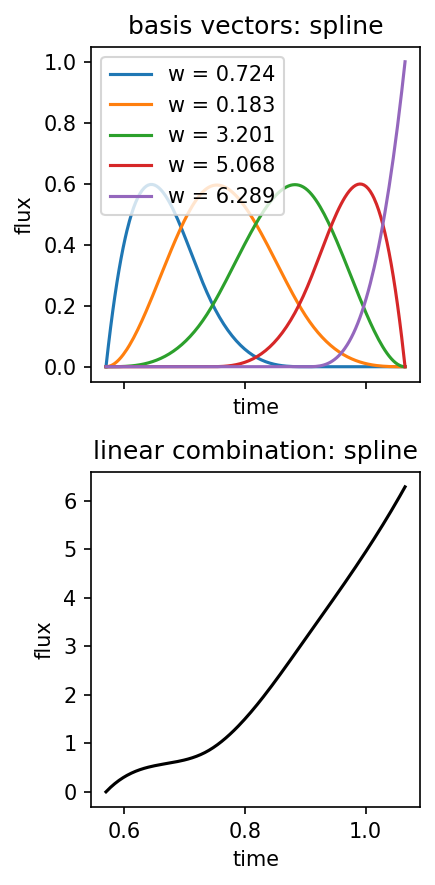

In [107]:
style = 1
name = 's25-1'
# fit.plot_systematics(name, style=style)

trend = fit.fit_params['data'][name]['trend']
ntrend = trend if trend else 0
spline = fit.fit_params['data'][name]['spline']
nspline = 5 if spline else 0    
bias = fit.fit_params['data'][name]['add_bias']
nbias = 1 if bias else 0

x = fit.data[name]['x']
X = fit.data[name]['X']
mask = fit.masks[name]
if mask is None:
    mask = np.ones(len(x), dtype=bool)
w = fit.map_soln[f'{name}_weights']
covariates = not X.shape[1] == nspline + ntrend + nbias
ncovariates = X.shape[1] - ntrend - nspline - nbias

x_ = x[mask]
X_cov = X[mask,:ncovariates]
X_tre = X[mask,ncovariates:(ncovariates+ntrend)]
X_spl = X[mask,(ncovariates+ntrend):(ncovariates+ntrend+nspline)]
w_cov = w[:ncovariates]
w_tre = w[ncovariates:(ncovariates+ntrend)]
w_spl = w[(ncovariates+ntrend):(ncovariates+ntrend+nspline)]

if style == 1:

    if covariates and spline:
        fig, axs = plt.subplots(2, 2, figsize=(6,6), sharex=True)
    elif covariates or spline:
        fig, axs = plt.subplots(2, 1, figsize=(3,6), sharex=True)

    def plot(axs, x, X, w, name):
        # axs[0].plot(x, X)
        for i,y in enumerate(X.T):
            axs[0].plot(x, y, label=f'w = {w[i] :.3f}')
        axs[0].legend()
        axs[1].plot(x, np.dot(X,w), color='k')
        plt.setp(axs[0], title=f'basis vectors: {name}')
        plt.setp(axs[1], title=f'linear combination: {name}')
        
    if covariates and not spline:
        plot(axs, x_, X_cov, w_cov, 'covariates')

    elif spline and not covariates:
        plot(axs, x_, X_spl, w_spl, 'spline')

    elif spline and covariates:
        plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
        plot(axs[:,1], x_, X_spl, w_spl, 'spline')

    plt.setp(axs, xlabel='time', ylabel='flux')
    fig.tight_layout()

elif style == 2:

    if covariates and spline:
        nax = 3
        fig, axs = plt.subplots(1, 3, figsize=(9,3), sharex=True)
    elif covariates or spline:
        nax = 1
        fig, ax = plt.subplots(1, 1, figsize=(3,3), sharex=True)

    def plot(ax, x, X, w, name):
        for i,y in enumerate(X.T):
            ax.plot(x, y, label=f'w = {w[i] :.3f}')
        ax.plot(x, np.dot(X,w), color='k', label=f'sum')
        ax.legend()
        plt.setp(ax, title=f'{name}')

    if covariates and not spline:
        plot(ax, x_, X_cov, w_cov, 'covariates')
        
    elif spline and not covariates:
        plot(ax, x_, X_spl, w_spl, 'spline')

    elif spline and covariates:
        plot(axs[0], x_, X_cov, w_cov, 'covariates')
        plot(axs[1], x_, X_spl, w_spl, 'spline')
        axs[2].plot(x_, np.dot(X_cov,w_cov)+np.dot(X_spl,w_spl), color='k')
        plt.setp(axs[2], title='sum')

    if nax == 1:
        plt.setp(ax, xlabel='time', ylabel='flux')
    else:
        plt.setp(axs, xlabel='time', ylabel='flux')
    fig.tight_layout()

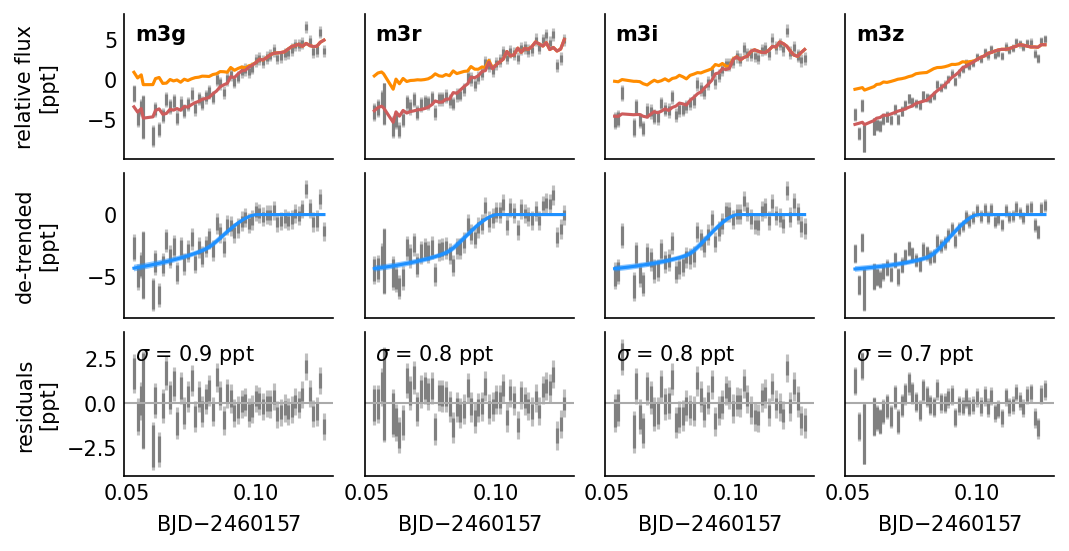

In [45]:
# fit.sample()
fit.plot_multi()

In [38]:
fit.summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t0[0],-0.034,0.002,-0.038,-0.031,0.000,0.000,3386.0,2356.0,1.00
b[0],0.340,0.134,0.085,0.570,0.004,0.003,1202.0,1076.0,1.00
dur[0],0.269,0.002,0.265,0.274,0.000,0.000,5866.0,3013.0,1.00
ror[0],0.066,0.002,0.062,0.069,0.000,0.000,5537.0,3098.0,1.00
m3g_log_sigma_lc[0],-0.441,0.184,-0.770,-0.086,0.003,0.002,4593.0,3120.0,1.00
m3r_log_sigma_lc[0],-0.390,0.166,-0.690,-0.078,0.002,0.002,4541.0,3143.0,1.00
m3i_log_sigma_lc[0],-0.369,0.162,-0.696,-0.089,0.002,0.002,4285.0,3183.0,1.00
m3z_log_sigma_lc[0],-1.617,1.894,-6.555,-0.308,0.179,0.127,259.0,164.0,1.01
